# 03 — QR Householder Experiments

Experiments with the compact thin QR factorization based on Householder reflectors (A2) for

$$
\min_w \left\|\hat{X}w-\hat{y}\right\|_2,
\qquad
\hat{X}=\begin{bmatrix}X^T\\ \lambda I_m\end{bmatrix},
\qquad
\hat{y}=\begin{bmatrix}y\\0\end{bmatrix}.
$$

We evaluate:

- the numerical accuracy of the individual Householder and compact-QR routines;
- solution accuracy against the same exact baseline used in the other experiment notebooks;
- sensitivity to $\lambda$ and to the condition number of $\hat{X}$;
- wall-time scaling with the problem dimension $m$.

In [1]:
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt

# Use a font that supports Unicode mathematical symbols.
plt.rcParams['font.family'] = 'DejaVu Sans'

from lib.qr_householder import (
    householder_vector,
    qr_factorize,
    apply_QT,
    back_substitution,
    qr_solve,
)
from lib.utils import (
    build_augmented_system,
    compute_condition_number,
    compute_gradient,
    compute_loss,
    load_ml_cup,
    relative_error,
    residual_norm,
    solve_exact,
)

## Data Setup

The experiments use the ML-CUP matrix and the deterministic target vector generated by `load_ml_cup`. The reference solution is computed with `solve_exact`, exactly as in the other experiment notebooks.

In [2]:
# Load the real dataset.
file_path = Path("dataset") / "ML-CUP25-TR.csv"
X, y, m, n = load_ml_cup(file_path, seed=42)
lam = 0.5

# Compute the exact solution used as the common baseline.
w_star, f_star, star_time = solve_exact(X, y, lam)
kappa = compute_condition_number(X, lam)

print(f"ML-CUP dataset loaded: m={m}, n={n}")
print(f"m={m}, n={n}, λ={lam}")
print(f"κ(X̂) = {kappa:.2f}")
print(f"f(w*) = {f_star:.10e}")
print(f"Exact baseline solve-stage time: {star_time:.5f}s")

ML-CUP dataset loaded: m=500, n=12
m=500, n=12, λ=0.5
κ(X̂) = 151.49
f(w*) = 9.2631982939e-02
Exact baseline solve-stage time: 0.07220s


## Factorization Accuracy

We first validate the public building blocks on a small subset of the data. The full matrix $Q$ is formed here only as a diagnostic; `qr_factorize`, `apply_QT`, and `qr_solve` never form it during normal use.

The relevant errors are

$$
\frac{\|\hat{X}-Q[R;0]\|_F}{\|\hat{X}\|_F},
\qquad
\frac{\|Q^TQ-I\|_F}{\|I\|_F},
\qquad
\frac{\|R^TR-\hat{X}^T\hat{X}\|_F}{\|\hat{X}^T\hat{X}\|_F}.
$$

In [3]:
machine_epsilon = np.finfo(float).eps

# Check one reflector directly.
probe = np.array([3.0, -4.0, 2.0, 1.0])
u_probe, s_probe = householder_vector(probe)
reflected_probe = probe - 2.0 * u_probe * np.dot(u_probe, probe)
probe_target = np.zeros_like(probe)
probe_target[0] = s_probe
reflector_error = np.linalg.norm(reflected_probe - probe_target) / np.linalg.norm(probe)

# Use the generic compact QR routines on a small augmented system.
m_small = min(60, m)
X_small = X[:m_small, :]
X_hat_small, y_hat_small = build_augmented_system(X_small, y, lam)
rows_small = X_hat_small.shape[0]

R_small, u_list_small = qr_factorize(X_hat_small)

# Reconstruct Q^T from the stored reflectors for diagnostics only.
QT_small = np.eye(rows_small)
for k, u_k in enumerate(u_list_small):
    QT_small[k:, :] -= 2.0 * np.outer(u_k, u_k @ QT_small[k:, :])

reduced_target = np.zeros_like(X_hat_small)
reduced_target[:m_small, :] = R_small
Q_small = QT_small.T

backward_error = (
    np.linalg.norm(X_hat_small - Q_small @ reduced_target, ord='fro')
    / np.linalg.norm(X_hat_small, ord='fro')
)
orthogonality_error = (
    np.linalg.norm(QT_small @ Q_small - np.eye(rows_small), ord='fro')
    / np.sqrt(rows_small)
)
gram_error = (
    np.linalg.norm(R_small.T @ R_small - X_hat_small.T @ X_hat_small, ord='fro')
    / np.linalg.norm(X_hat_small.T @ X_hat_small, ord='fro')
)

# Verify the implicit Q^T product and the triangular solve.
qt_y_small = apply_QT(u_list_small, y_hat_small, rows_small)
implicit_product_error = (
    np.linalg.norm(qt_y_small - QT_small @ y_hat_small)
    / np.linalg.norm(y_hat_small)
)
w_components = back_substitution(R_small, qt_y_small[:m_small])
w_star_small, _, _ = solve_exact(X_small, y, lam)
component_solution_error = relative_error(w_components, w_star_small)

print(f"Machine epsilon:              {machine_epsilon:.3e}")
print(f"Householder action error:     {reflector_error:.3e}")
print(f"QR backward error:            {backward_error:.3e}")
print(f"Orthogonality error:          {orthogonality_error:.3e}")
print(f"RᵀR consistency error:        {gram_error:.3e}")
print(f"Implicit Qᵀ product error:    {implicit_product_error:.3e}")
print(f"Component solution rel. error:{component_solution_error: .3e}")

Machine epsilon:              2.220e-16
Householder action error:     1.869e-16
QR backward error:            5.618e-16
Orthogonality error:          7.058e-16
RᵀR consistency error:        5.166e-16
Implicit Qᵀ product error:    6.204e-16
Component solution rel. error: 7.347e-14


Results:

- The reflector eliminates every component below the first without explicitly constructing a dense transformation matrix.
- The reconstruction, orthogonality, and $R^TR$ consistency errors should remain close to floating-point precision.
- `apply_QT` reproduces the explicit diagnostic product, while `back_substitution` recovers the baseline solution.

## End-to-End Solution Accuracy

The production call is `qr_solve(X, y, lam)`. It exploits the structure of the regularization block, stores compact Householder vectors, applies $Q^T$ implicitly, and solves the resulting triangular system.

In [4]:
w_qr, _ = qr_solve(X, y, lam)
f_qr = compute_loss(w_qr, X, y, lam)

baseline_residual = residual_norm(w_star, X, y, lam)
qr_residual = residual_norm(w_qr, X, y, lam)
qr_solution_error = relative_error(w_qr, w_star)
qr_objective_gap = abs(f_qr - f_star) / max(abs(f_star), machine_epsilon)

# Check first-order optimality with the shared gradient implementation.
qr_gradient = compute_gradient(w_qr, X, y, lam)
stationarity_error = np.linalg.norm(qr_gradient) / max(np.linalg.norm(X @ y), 1.0)

print(f"{'Method':<18} {'f(w)':>15} {'rel. w error':>15} {'norm. residual':>16}")
print('-' * 68)
print(f"{'Exact baseline':<18} {f_star:>15.7e} {0.0:>15.3e} "
      f"{baseline_residual:>16.3e}")
print(f"{'Householder QR':<18} {f_qr:>15.7e} {qr_solution_error:>15.3e} "
      f"{qr_residual:>16.3e}")
print()
print(f"Relative objective gap: {qr_objective_gap:.3e}")
print(f"Relative stationarity error: {stationarity_error:.3e}")

Method                        f(w)    rel. w error   norm. residual
--------------------------------------------------------------------
Exact baseline       9.2631983e-02       0.000e+00        1.610e-01
Householder QR       9.2631983e-02       6.041e-13        1.610e-01

Relative objective gap: 0.000e+00
Relative stationarity error: 1.120e-15


Results:

- Householder QR and the exact baseline minimize the same regularized least-squares objective.
- A nonzero normalized residual is expected because the problem is a least-squares problem; accuracy is assessed by agreement with the baseline, the objective gap, and first-order stationarity.
- The QR implementation reaches the solution using orthogonal transformations and never forms the normal-equation matrix.

## Effect of $\lambda$ and Conditioning

We use the same range of regularization parameters as the other experiments. Smaller $\lambda$ increases

$$
\kappa(\hat{X})=
\sqrt{\frac{\lambda_{\max}(XX^T)+\lambda^2}
{\lambda_{\min}(XX^T)+\lambda^2}},
$$

making the solution more sensitive to rounding errors.

In [5]:
lambda_values = [1e-4, 1e-2, 0.5, 1.0, 1e2, 1e4]
lambda_results = []

print(f"{'λ':>9} {'κ(X̂)':>13} {'rel. w error':>15} "
      f"{'rel. f gap':>13} {'norm. residual':>16}")
print('-' * 72)

for lam_value in lambda_values:
    w_reference, f_reference, _ = solve_exact(X, y, lam_value)
    w_value, _ = qr_solve(X, y, lam_value)
    f_value = compute_loss(w_value, X, y, lam_value)

    result = {
        'lam': lam_value,
        'kappa': compute_condition_number(X, lam_value),
        'solution_error': relative_error(w_value, w_reference),
        'objective_gap': abs(f_value - f_reference) / max(abs(f_reference), machine_epsilon),
        'residual': residual_norm(w_value, X, y, lam_value),
    }
    lambda_results.append(result)

    print(f"{lam_value:>9.0e} {result['kappa']:>13.3e} "
          f"{result['solution_error']:>15.3e} {result['objective_gap']:>13.3e} "
          f"{result['residual']:>16.3e}")

        λ         κ(X̂)    rel. w error    rel. f gap   norm. residual
------------------------------------------------------------------------
    1e-04     7.575e+05       1.403e-05     1.969e-10        3.278e-05
    1e-02     7.575e+03       1.400e-09     0.000e+00        3.278e-03
    5e-01     1.515e+02       6.041e-13     0.000e+00        1.610e-01
    1e+00     7.575e+01       1.477e-13     0.000e+00        3.067e-01
    1e+02     1.254e+00       1.638e-15     0.000e+00        9.655e-01
    1e+04     1.000e+00       1.474e-15     0.000e+00        1.000e+00


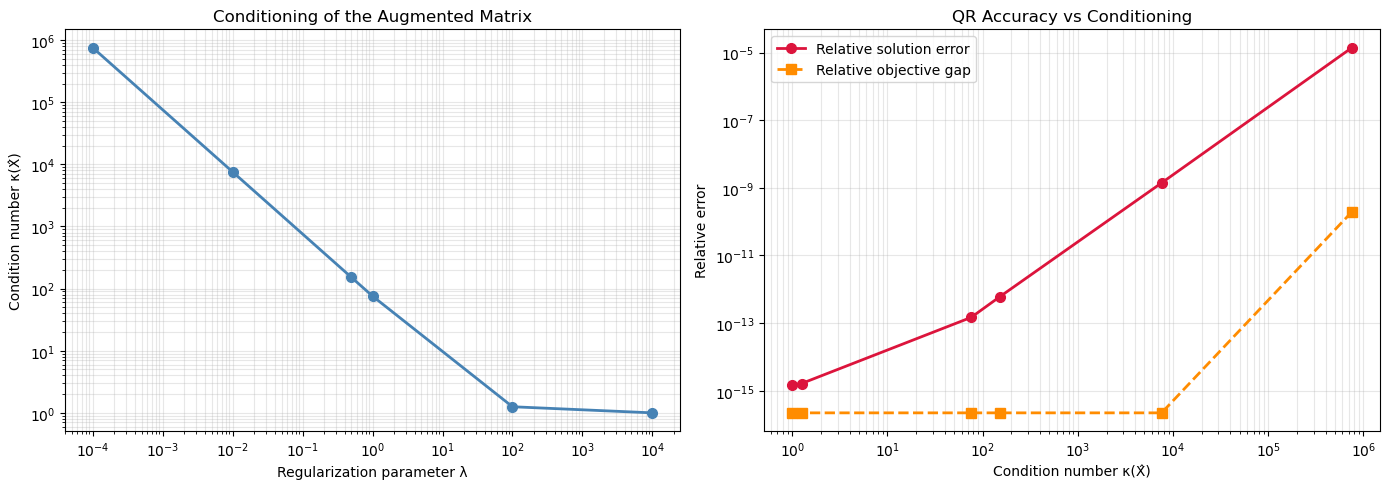

In [6]:
lambdas_plot = np.array([row['lam'] for row in lambda_results])
kappas_plot = np.array([row['kappa'] for row in lambda_results])
solution_errors = np.array([row['solution_error'] for row in lambda_results])
objective_gaps = np.array([row['objective_gap'] for row in lambda_results])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].loglog(lambdas_plot, kappas_plot, 'o-', lw=2, ms=7, color='steelblue')
axes[0].set(
    xlabel='Regularization parameter λ',
    ylabel='Condition number κ(X̂)',
    title='Conditioning of the Augmented Matrix',
)
axes[0].grid(alpha=0.3, which='both')

axes[1].loglog(
    kappas_plot,
    np.maximum(solution_errors, machine_epsilon),
    'o-', lw=2, ms=7, color='crimson', label='Relative solution error',
)
axes[1].loglog(
    kappas_plot,
    np.maximum(objective_gaps, machine_epsilon),
    's--', lw=2, ms=7, color='darkorange', label='Relative objective gap',
)
axes[1].set(
    xlabel='Condition number κ(X̂)',
    ylabel='Relative error',
    title='QR Accuracy vs Conditioning',
)
axes[1].legend()
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

Results:

- Increasing $\lambda$ improves the conditioning of the augmented matrix.
- For moderate and large $\lambda$, the QR and normal-equation baseline solutions agree to nearly machine precision.
- At very small $\lambda$, a larger difference from `solve_exact` is expected because the baseline explicitly forms $XX^T+\lambda^2I$, whose condition number is $\kappa(\hat{X})^2$. QR avoids this squaring, so the disagreement should not be interpreted automatically as a QR failure.

## Computational Scalability

The structured QR solver costs $O(nm^2+m^2)$, while the exact baseline builds and solves a dense $m\times m$ normal-equation system. We measure complete function calls after one warm-up and report the median, which reduces timer noise.

In [7]:
def median_wall_time(function, *args, repeats=5):
    """Return the median wall time after one untimed warm-up call."""
    function(*args)
    timings = []
    for _ in range(repeats):
        start = time.perf_counter()
        function(*args)
        timings.append(time.perf_counter() - start)
    return float(np.median(timings))

In [8]:
# Scale over nested subsets of the real ML-CUP matrix.
real_m_sizes = sorted(set([50, 100, 200, 350, m]))
real_scaling = []

print("Real ML-CUP subsets")
print(f"{'m':>6} {'QR total (ms)':>15} {'baseline (ms)':>15} {'rel. w error':>15}")
print('-' * 58)

for m_value in real_m_sizes:
    X_value = X[:m_value, :]
    w_reference, _, _ = solve_exact(X_value, y, lam)
    w_value, _ = qr_solve(X_value, y, lam)

    row = {
        'm': m_value,
        'qr_time': median_wall_time(qr_solve, X_value, y, lam),
        'baseline_time': median_wall_time(solve_exact, X_value, y, lam),
        'solution_error': relative_error(w_value, w_reference),
    }
    real_scaling.append(row)
    print(f"{m_value:>6d} {row['qr_time'] * 1e3:>15.3f} "
          f"{row['baseline_time'] * 1e3:>15.3f} {row['solution_error']:>15.3e}")

Real ML-CUP subsets
     m   QR total (ms)   baseline (ms)    rel. w error
----------------------------------------------------------
    50           1.822           0.047       6.966e-14
   100           3.677           0.126       1.106e-13
   200          10.144           0.892       2.493e-13
   350          30.765          10.571       3.748e-13
   500          41.201           7.762       6.041e-13


In [9]:
# Use nested synthetic matrices to expose the asymptotic trend beyond the dataset size.
rng = np.random.default_rng(0)
synthetic_m_sizes = [250, 500, 1000, 2000]
X_synthetic_full = rng.standard_normal((max(synthetic_m_sizes), n))
y_synthetic = rng.standard_normal(n)
synthetic_scaling = []

print("Synthetic data with n=12")
print(f"{'m':>6} {'QR total (ms)':>15} {'baseline (ms)':>15} {'rel. w error':>15}")
print('-' * 58)

for m_value in synthetic_m_sizes:
    X_value = X_synthetic_full[:m_value, :]
    w_reference, _, _ = solve_exact(X_value, y_synthetic, lam)
    w_value, _ = qr_solve(X_value, y_synthetic, lam)

    row = {
        'm': m_value,
        'qr_time': median_wall_time(qr_solve, X_value, y_synthetic, lam, repeats=3),
        'baseline_time': median_wall_time(solve_exact, X_value, y_synthetic, lam, repeats=3),
        'solution_error': relative_error(w_value, w_reference),
    }
    synthetic_scaling.append(row)
    print(f"{m_value:>6d} {row['qr_time'] * 1e3:>15.3f} "
          f"{row['baseline_time'] * 1e3:>15.3f} {row['solution_error']:>15.3e}")

synthetic_m = np.array([row['m'] for row in synthetic_scaling], dtype=float)
synthetic_qr_times = np.array([row['qr_time'] for row in synthetic_scaling])
synthetic_baseline_times = np.array([row['baseline_time'] for row in synthetic_scaling])
qr_empirical_order = np.polyfit(np.log(synthetic_m), np.log(synthetic_qr_times), 1)[0]
baseline_empirical_order = np.polyfit(
    np.log(synthetic_m), np.log(synthetic_baseline_times), 1
)[0]

print()
print(f"Empirical QR timing exponent:       {qr_empirical_order:.2f}")
print(f"Empirical baseline timing exponent: {baseline_empirical_order:.2f}")

Synthetic data with n=12
     m   QR total (ms)   baseline (ms)    rel. w error
----------------------------------------------------------
   250          50.227          23.230       2.041e-13
   500          38.236           7.218       3.994e-13
  1000          63.654          54.228       7.609e-13
  2000         138.503         415.806       1.680e-12

Empirical QR timing exponent:       0.51
Empirical baseline timing exponent: 1.54


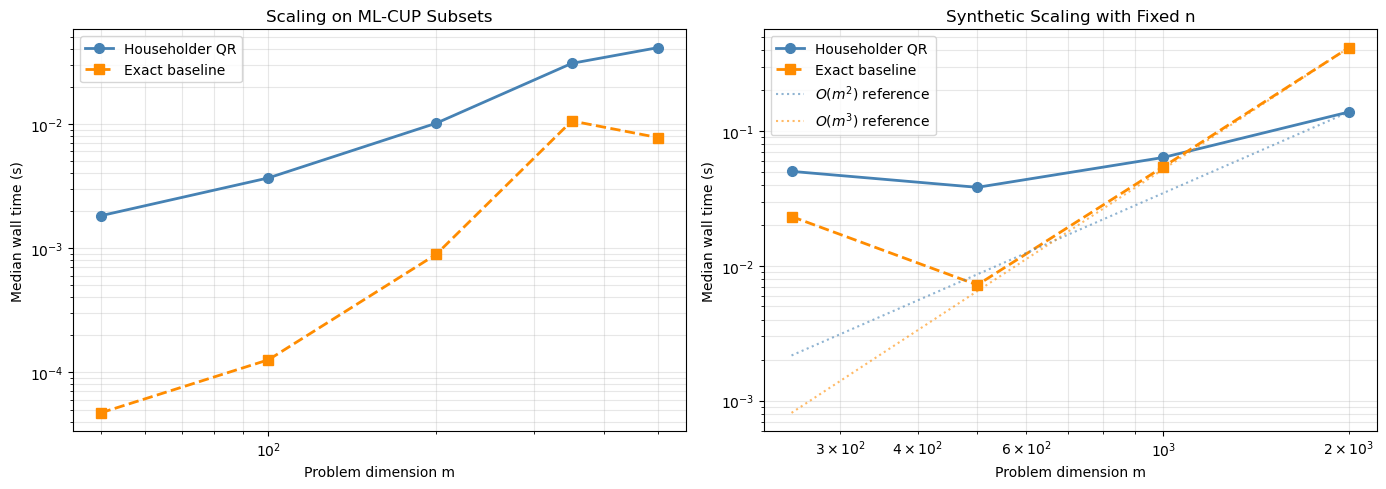

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

real_m = np.array([row['m'] for row in real_scaling])
real_qr_times = np.array([row['qr_time'] for row in real_scaling])
real_baseline_times = np.array([row['baseline_time'] for row in real_scaling])

axes[0].loglog(real_m, real_qr_times, 'o-', lw=2, ms=7,
               color='steelblue', label='Householder QR')
axes[0].loglog(real_m, real_baseline_times, 's--', lw=2, ms=7,
               color='darkorange', label='Exact baseline')
axes[0].set(
    xlabel='Problem dimension m',
    ylabel='Median wall time (s)',
    title='Scaling on ML-CUP Subsets',
)
axes[0].legend()
axes[0].grid(alpha=0.3, which='both')

axes[1].loglog(synthetic_m, synthetic_qr_times, 'o-', lw=2, ms=7,
               color='steelblue', label='Householder QR')
axes[1].loglog(synthetic_m, synthetic_baseline_times, 's--', lw=2, ms=7,
               color='darkorange', label='Exact baseline')

# Add theoretical reference slopes anchored at the largest problem.
quadratic_reference = synthetic_qr_times[-1] * (synthetic_m / synthetic_m[-1]) ** 2
cubic_reference = synthetic_baseline_times[-1] * (synthetic_m / synthetic_m[-1]) ** 3
axes[1].loglog(synthetic_m, quadratic_reference, ':', color='steelblue', alpha=0.6,
               label='$O(m^2)$ reference')
axes[1].loglog(synthetic_m, cubic_reference, ':', color='darkorange', alpha=0.6,
               label='$O(m^3)$ reference')
axes[1].set(
    xlabel='Problem dimension m',
    ylabel='Median wall time (s)',
    title='Synthetic Scaling with Fixed n',
)
axes[1].legend()
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

Results:

- The structured Householder implementation processes only one active row of $R$ and the $n$ dense rows at each step, giving $O(nm^2+m^2)$ work and compact $O(nm)$ reflector storage.
- The baseline solves a dense $m\times m$ system and therefore has cubic asymptotic cost, although optimized BLAS/LAPACK routines can be faster for moderate dimensions.
- The repeated median timings should be interpreted together with the reference slopes; cache behavior, threading, and Python overhead affect the empirical exponents at small sizes.
- Solution agreement remains close to floating-point precision throughout the scaling experiment.

## Summary

- The individual reflector, factorization, implicit-$Q^T$, and triangular-solve routines pass direct numerical consistency checks.
- `qr_solve` matches the common `solve_exact` baseline closely at moderate conditioning while avoiding normal equations.
- Householder QR is especially valuable for ill-conditioned problems because orthogonal transformations do not square the condition number.
- Exploiting the $\lambda I_m$ block keeps the project solver quadratic in the large dimension $m$ when $n$ is fixed.